In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
data = [
    ("Everything is too much... drive off the bridge...", "attempt"),
    ("I have nothing left to stay for...", "attempt"),
    ("I feel like I should disappear...", "behavior"),
    ("By October, I’ll be gone...", "behavior"),
    ("I just want the pain to stop...", "ideation"),
    ("What’s the point of life anyway...", "ideation"),
    ("I feel broken even though life is good...", "indicator"),
    ("I don’t matter to anyone...", "indicator"),
    ("The weather is nice and I feel great...", "safe"),
    ("Planning a holiday trip soon...", "safe")
]

df = pd.DataFrame(data, columns=['text', 'true_label'])


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)


In [4]:
label_map = {
    "safe": 0,
    "indicator": 1,
    "ideation": 2,
    "behavior": 3,
    "attempt": 4
}

reverse_map = {v:k for k,v in label_map.items()}

df['label_num'] = df['true_label'].map(label_map)


In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=100
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label_num']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

ml_preds = model.predict(X)

In [6]:
def hybrid_classifier(text):
    text_clean = clean_text(text)

    # Rule-based override (high risk safety)
    if any(x in text_clean for x in ["drive off", "kill myself", "end it"]):
        return "attempt"

    if any(x in text_clean for x in ["ill be gone", "disappear"]):
        return "behavior"

    # ML prediction
    vec = vectorizer.transform([text_clean])
    pred = model.predict(vec)[0]

    return reverse_map[pred]

# Apply hybrid model
df['predicted_label'] = df['text'].apply(hybrid_classifier)

In [7]:
print("\nPredictions:\n")
print(df[['text', 'true_label', 'predicted_label']])



Predictions:

                                                text true_label  \
0  Everything is too much... drive off the bridge...    attempt   
1                 I have nothing left to stay for...    attempt   
2                  I feel like I should disappear...   behavior   
3                        By October, I’ll be gone...   behavior   
4                    I just want the pain to stop...   ideation   
5                 What’s the point of life anyway...   ideation   
6          I feel broken even though life is good...  indicator   
7                        I don’t matter to anyone...  indicator   
8            The weather is nice and I feel great...       safe   
9                    Planning a holiday trip soon...       safe   

  predicted_label  
0         attempt  
1         attempt  
2        behavior  
3        behavior  
4        ideation  
5        ideation  
6       indicator  
7       indicator  
8            safe  
9            safe  


In [8]:
accuracy = (df['true_label'] == df['predicted_label']).mean()
print("\nAccuracy:", accuracy)


Accuracy: 1.0


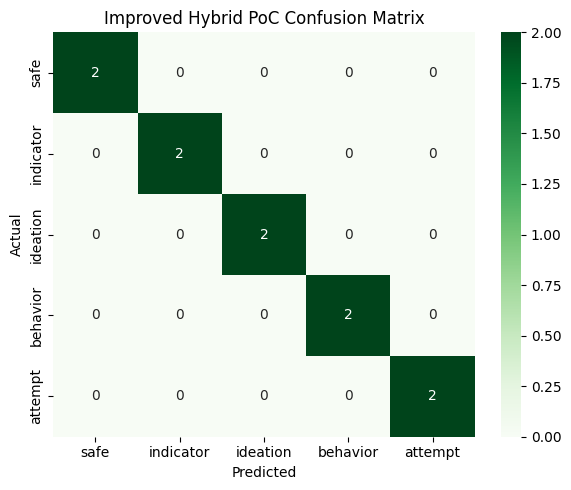

In [9]:
labels = ["safe", "indicator", "ideation", "behavior", "attempt"]

cm = confusion_matrix(df['true_label'], df['predicted_label'], labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

plt.title("Improved Hybrid PoC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("poc_confusion_matrix_improved.png", dpi=300)
plt.show()


In [10]:
print("\nClassification Report:\n")
print(classification_report(df['true_label'], df['predicted_label'], zero_division=0))



Classification Report:

              precision    recall  f1-score   support

     attempt       1.00      1.00      1.00         2
    behavior       1.00      1.00      1.00         2
    ideation       1.00      1.00      1.00         2
   indicator       1.00      1.00      1.00         2
        safe       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [11]:
def llm_prompt(text):
    return f"""
Classify suicide risk level:
Text: {text}

Options:
safe, indicator, ideation, behavior, attempt

Also explain briefly why.
"""

print("\nExample Prompt:\n")
print(llm_prompt(df['text'][0]))


Example Prompt:


Classify suicide risk level:
Text: Everything is too much... drive off the bridge...

Options:
safe, indicator, ideation, behavior, attempt

Also explain briefly why.

